In [1]:
%load_ext autoreload
%autoreload 0

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(Path().resolve().parents[1]))

In [3]:
import os
import re

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from io import StringIO
import pandas as pd
import pickle
import igraph as ig
import torch



In [ ]:
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()


from dataset import CachedDataset
from collate import collate_fn

from model import DiffusionGNN
from diff_util import create_diffusion, preprocess


# ----------------------------------
# Config
# ----------------------------------

BATCH_SIZE = 32          # you can increase now
LR = 2e-4
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NODE_DIM = 3
HIDDEN = 128
TIMESTEPS = 1000
MAX_NODES = 300  

# ----------------------------------
# Dataset
# ----------------------------------

dataset = CachedDataset("cached_dataset.pt", max_nodes=MAX_NODES)
print(f"Dataset size: {len(dataset)}")

loader = DataLoader(

    dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    collate_fn=collate_fn,

    num_workers=0,      # IMPORTANT
    pin_memory=False,    # IMPORTANT

    persistent_workers=False,
)

print(f"Number of batches: {len(loader)}")
model = DiffusionGNN(
    node_dim=NODE_DIM,
    hidden_dim=HIDDEN,
    num_layers=4
).to(DEVICE)

diffusion = create_diffusion(TIMESTEPS)
print(f"Model and diffusion created on {DEVICE}")

optimizer = Adam(model.parameters(), lr=LR)


# ----------------------------------
# Training
# ----------------------------------

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    print(f"Epoch {epoch+1}/{EPOCHS} | Training...")

    for x, adj, node_mask in loader:

        x = x.to(DEVICE, dtype=torch.float16)
        adj = adj.to(DEVICE, dtype=torch.float16) # 500 x 500 adjacency matrix = 250,000 entries = 4000 x 4000 x 4 bytes = 64 MB per graph, batch size 2 = 128 MB just for adj, plus node features and other tensors, so we need to be careful with memory
        node_mask = node_mask.to(DEVICE, dtype=torch.float16)

        # print(adj.shape, node_mask.shape)

        # Mask adj
        adj = adj * node_mask[:, :, None] * node_mask[:, None, :]
        # print(adj.shape, node_mask.shape)
        # print(adj)
        # break
        B = x.shape[0]


        t = torch.randint(
            0,
            diffusion.num_timesteps,
            (B,),
            device=DEVICE
        )


        with autocast():

            loss_dict = diffusion.training_losses(
                model,
                x_start=x,
                t=t,
                model_kwargs={
                    "adj": adj,
                    "node_mask": node_mask
                }
            )

            loss = loss_dict["loss"].mean()


        optimizer.zero_grad()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()


        total_loss += loss.item()


    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")


    torch.save(model.state_dict(), "model.pt")

Filtered dataset: 2724 → 2262 graphs (max_nodes=300)
Dataset size: 2262
Number of batches: 71
Model and diffusion created on cuda
Epoch 1/100 | Training...
Epoch 1 | Loss: 5.9125
Epoch 2/100 | Training...
Epoch 2 | Loss: 1.4449
Epoch 3/100 | Training...
Epoch 3 | Loss: 1.2301
Epoch 4/100 | Training...
Epoch 4 | Loss: 1.1202
Epoch 5/100 | Training...
Epoch 5 | Loss: 1.0435
Epoch 6/100 | Training...
Epoch 6 | Loss: 0.9792
Epoch 7/100 | Training...
Epoch 7 | Loss: 0.9606
Epoch 8/100 | Training...
Epoch 8 | Loss: 0.9414
Epoch 9/100 | Training...
Epoch 9 | Loss: 0.9268
Epoch 10/100 | Training...
Epoch 10 | Loss: 0.8843
Epoch 11/100 | Training...
Epoch 11 | Loss: 0.8839
Epoch 12/100 | Training...
Epoch 12 | Loss: 0.9085
Epoch 13/100 | Training...
Epoch 13 | Loss: 0.8631
Epoch 14/100 | Training...
Epoch 14 | Loss: 0.8379
Epoch 15/100 | Training...
Epoch 15 | Loss: 0.8393
Epoch 16/100 | Training...
Epoch 16 | Loss: 0.8748
Epoch 17/100 | Training...
Epoch 17 | Loss: 0.8433
Epoch 18/100 | Traini

In [5]:

# ============================================================
# Inspection setup — run this cell before the ones below
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from dataset import CachedDataset
from model import DiffusionGNN
from diff_util import create_diffusion

# Load dataset and pick a sample with at least 6 nodes
dataset    = CachedDataset("cached_dataset.pt")
sample_idx = next(i+4 for i, (x, _) in enumerate(dataset) if x.shape[0] >= 6)
x_orig, adj_orig = dataset[sample_idx]
N = x_orig.shape[0]

print(f"Sample index : {sample_idx}")
print(f"Nodes        : {N}")
print(f"Node features (laundering, degree, depth):\n{x_orig}")

# Add batch dimension — all inspection cells work with [1, N, ...] tensors
x_batch   = x_orig.unsqueeze(0).float().to(DEVICE)   # [1, N, 3]
adj_batch = adj_orig.unsqueeze(0).float().to(DEVICE)  # [1, N, N]
node_mask = torch.ones(1, N, device=DEVICE)           # [1, N]

# Load trained model
model = DiffusionGNN(node_dim=NODE_DIM, hidden_dim=HIDDEN, num_layers=4).to(DEVICE)
model.load_state_dict(torch.load("model.pt", map_location=DEVICE))
model.eval()
print(f"\nModel loaded on {DEVICE}")

diffusion = create_diffusion(TIMESTEPS)
print("Diffusion created.")


Sample index : 5
Nodes        : 227
Node features (laundering, degree, depth):
tensor([[  1.,   4.,   0.],
        [  0.,   6.,   4.],
        [  0.,  41.,   3.],
        [  0.,   4.,   4.],
        [  0., 117.,   3.],
        [  0.,  24.,   4.],
        [  0.,  52.,   4.],
        [  0.,  70.,   2.],
        [  0.,  22.,   4.],
        [  1.,   7.,   0.],
        [  1.,  40.,   0.],
        [  0.,  18.,   4.],
        [  0.,   8.,   4.],
        [  0.,   7.,   4.],
        [  0.,  25.,   4.],
        [  0.,  22.,   4.],
        [  0.,  25.,   4.],
        [  0.,  69.,   2.],
        [  0.,   3.,   4.],
        [  0.,  71.,   2.],
        [  0.,  95.,   3.],
        [  0.,  96.,   3.],
        [  0.,  50.,   3.],
        [  0.,   3.,   4.],
        [  0.,  10.,   4.],
        [  0.,   3.,   4.],
        [  0.,  26.,   3.],
        [  0.,   5.,   4.],
        [  0.,   2.,   4.],
        [  0., 125.,   3.],
        [  0.,  11.,   4.],
        [  0.,  18.,   4.],
        [  0.,  55.,   2.

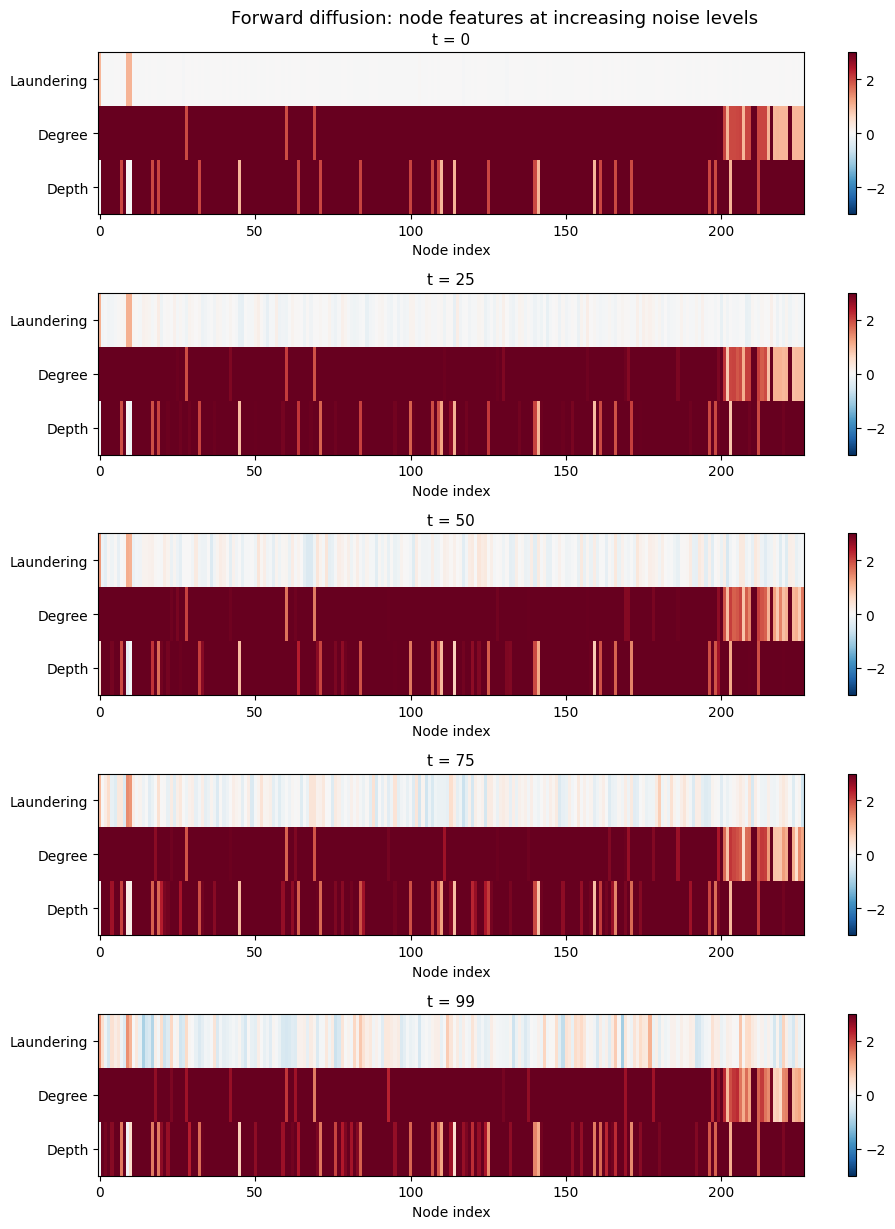

In [6]:

# ============================================================
# 1. Forward corruption — q_sample at increasing timesteps
# ============================================================

checkpoints   = [0, 25, 50, 75, 99]
feature_names = ["Laundering", "Degree", "Depth"]

fig, axes = plt.subplots(len(checkpoints), 1, figsize=(10, 2.5 * len(checkpoints)))

with torch.no_grad():
    for ax, t_val in zip(axes, checkpoints):
        t_tensor = torch.tensor([t_val], device=DEVICE)
        x_t = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)
        data = x_t[0].cpu().float().numpy()   # [N, 3]
        im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
        ax.set_title(f"t = {t_val}", fontsize=11)
        ax.set_yticks(range(3))
        ax.set_yticklabels(feature_names)
        ax.set_xlabel("Node index")
        plt.colorbar(im, ax=ax)

plt.suptitle("Forward diffusion: node features at increasing noise levels", fontsize=13)
plt.tight_layout()
plt.show()


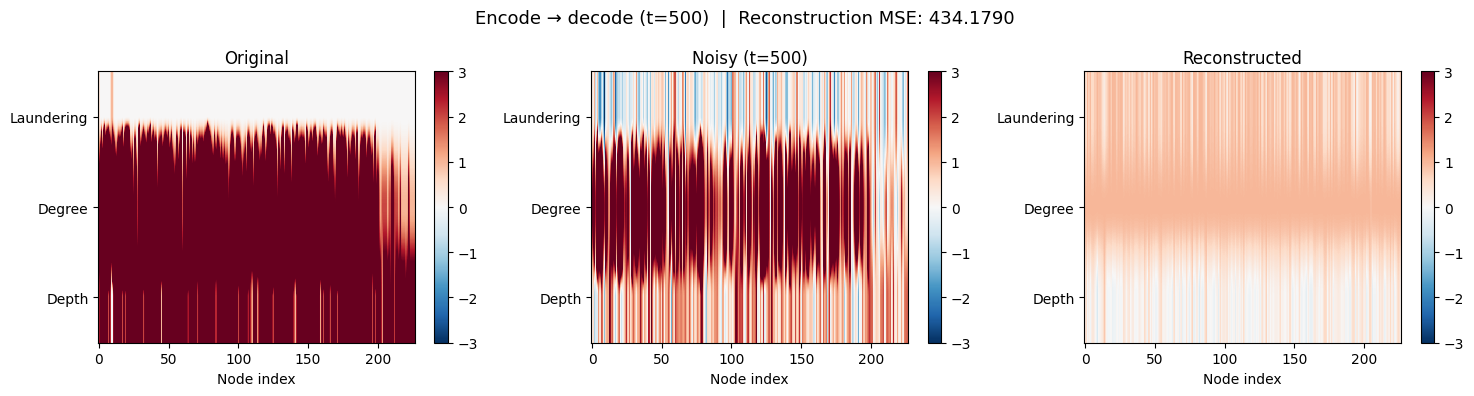

  Laundering   MSE: 0.5923
  Degree       MSE: 1289.8400
  Depth        MSE: 12.1045


In [7]:

# ============================================================
# 2. Encode → decode reconstruction at a chosen t
# ============================================================

def denoise_from_t(model, diffusion, x_t, adj, node_mask, start_t, device):
    """Run the reverse diffusion loop from `start_t` down to 0."""
    x = x_t.clone()
    with torch.no_grad():
        for i in reversed(range(start_t + 1)):
            t = torch.tensor([i] * x.shape[0], device=device)
            out = diffusion.p_sample(
                model, x, t,
                model_kwargs={"adj": adj, "node_mask": node_mask},
            )
            x = out["sample"]
    return x


T_ENCODE = 500   # noise level to encode to — try 25, 50, 75

with torch.no_grad():
    t_tensor = torch.tensor([T_ENCODE], device=DEVICE)
    x_noisy = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)

x_recon = denoise_from_t(model, diffusion, x_noisy, adj_batch, node_mask, T_ENCODE, DEVICE)

feature_names = ["Laundering", "Degree", "Depth"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, title, tensor in zip(
    axes,
    ["Original", f"Noisy (t={T_ENCODE})", "Reconstructed"],
    [x_batch,    x_noisy,                  x_recon],
):
    data = tensor[0].cpu().float().numpy()
    im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(title, fontsize=12)
    ax.set_yticks(range(3))
    ax.set_yticklabels(feature_names)
    ax.set_xlabel("Node index")
    plt.colorbar(im, ax=ax)

mse = ((x_batch.float() - x_recon.float()) ** 2).mean().item()
plt.suptitle(f"Encode → decode (t={T_ENCODE})  |  Reconstruction MSE: {mse:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

# Per-feature MSE
for i, name in enumerate(feature_names):
    feat_mse = ((x_batch[0, :, i].float() - x_recon[0, :, i].float()) ** 2).mean().item()
    print(f"  {name:12s} MSE: {feat_mse:.4f}")


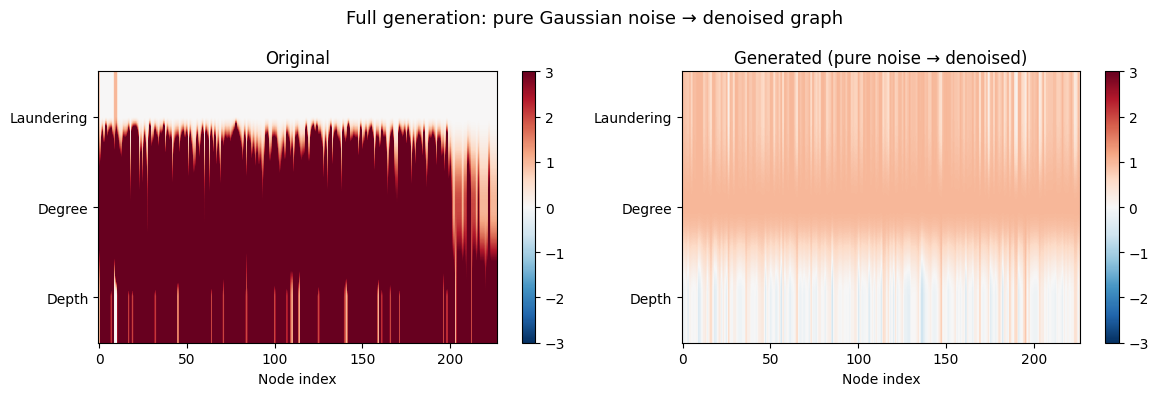

Laundering    orig mean=0.013  gen mean=0.814  orig std=0.114  gen std=0.184
Degree        orig mean=23.066  gen mean=1.000  orig std=28.336  gen std=0.000
Depth         orig mean=3.493  gen mean=0.023  orig std=0.852  gen std=0.233


In [8]:

# ============================================================
# 3. Full generation from pure noise (p_sample_loop)
# ============================================================
# Uses the real graph's adj + node_mask as conditioning structure,
# but starts node features from pure Gaussian noise.

shape = x_batch.shape  # [1, N, 3]

with torch.no_grad():
    x_generated = diffusion.p_sample_loop(
        model,
        shape,
        model_kwargs={"adj": adj_batch, "node_mask": node_mask},
        device=DEVICE,
    )

feature_names = ["Laundering", "Degree", "Depth"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, tensor in zip(
    axes,
    ["Original", "Generated (pure noise → denoised)"],
    [x_batch, x_generated],
):
    data = tensor[0].cpu().float().numpy()
    im = ax.imshow(data.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_title(title, fontsize=12)
    ax.set_yticks(range(3))
    ax.set_yticklabels(feature_names)
    ax.set_xlabel("Node index")
    plt.colorbar(im, ax=ax)

plt.suptitle("Full generation: pure Gaussian noise → denoised graph", fontsize=13)
plt.tight_layout()
plt.show()

# Distribution stats
orig_np = x_batch[0].cpu().float().numpy()
gen_np  = x_generated[0].cpu().float().numpy()
for i, name in enumerate(feature_names):
    print(f"{name:12s}  orig mean={orig_np[:, i].mean():.3f}  gen mean={gen_np[:, i].mean():.3f}  "
          f"orig std={orig_np[:, i].std():.3f}  gen std={gen_np[:, i].std():.3f}")


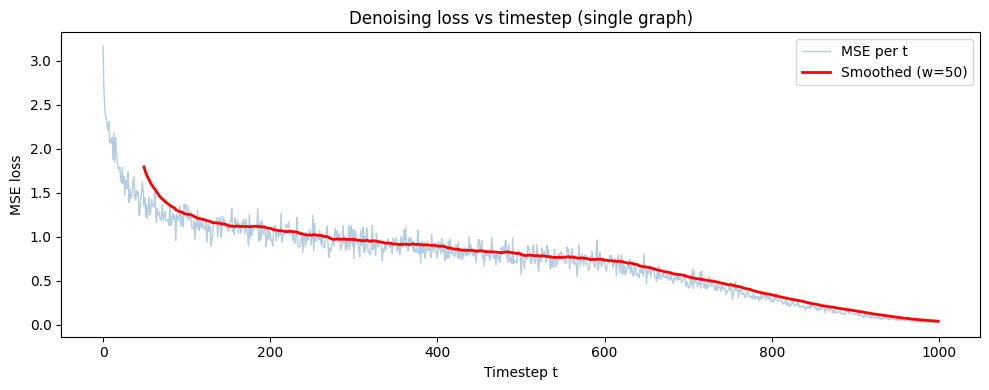

Easiest t (lowest loss): 997  loss=0.0231
Hardest t (highest loss): 0  loss=3.1634


In [9]:
losses_per_t = []

model.eval()
with torch.no_grad():
    for t_val in range(TIMESTEPS):
        t_tensor = torch.tensor([t_val], device=DEVICE)
        loss_dict = diffusion.training_losses(
            model,
            x_start=x_batch,
            t=t_tensor,
            model_kwargs={"adj": adj_batch, "node_mask": node_mask},
        )
        losses_per_t.append(loss_dict["loss"].item())

window = max(1, TIMESTEPS // 20)
smoothed = np.convolve(losses_per_t, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(range(TIMESTEPS), losses_per_t, alpha=0.4, linewidth=1, color="steelblue", label="MSE per t")
plt.plot(range(window - 1, TIMESTEPS), smoothed, linewidth=2, color="red", label=f"Smoothed (w={window})")
plt.xlabel("Timestep t")
plt.ylabel("MSE loss")
plt.title("Denoising loss vs timestep (single graph)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Easiest t (lowest loss): {int(np.argmin(losses_per_t))}  loss={min(losses_per_t):.4f}")
print(f"Hardest t (highest loss): {int(np.argmax(losses_per_t))}  loss={max(losses_per_t):.4f}")


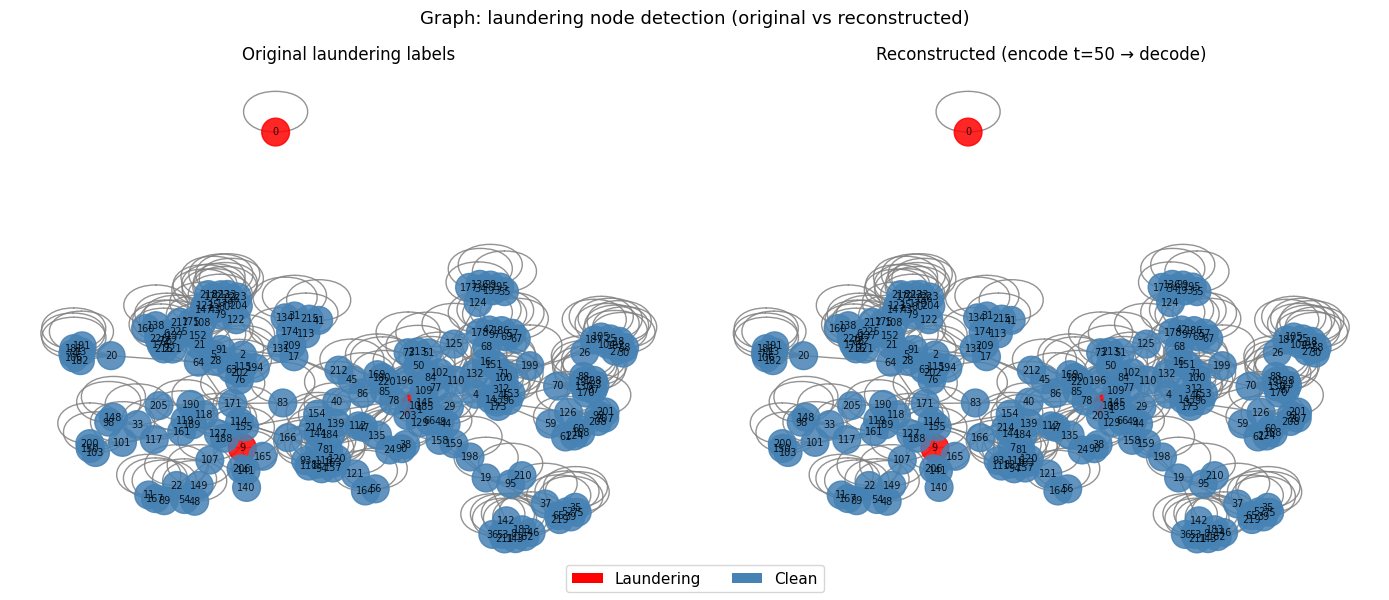

Laundering label accuracy after encode-decode: 100.00%


In [11]:
T_VIZ = 50

with torch.no_grad():
    t_tensor = torch.tensor([T_VIZ], device=DEVICE)
    x_noisy_viz = diffusion.q_sample(x_batch, t_tensor, node_mask=node_mask)

x_recon_viz = denoise_from_t(model, diffusion, x_noisy_viz, adj_batch, node_mask, T_VIZ, DEVICE)

adj_np       = adj_orig.cpu().numpy()
G            = nx.from_numpy_array(adj_np)
pos          = nx.spring_layout(G, seed=42)

orig_labels  = x_orig[:, 0].numpy()                        # feature 0 = laundering
recon_labels = x_recon_viz[0, :, 0].cpu().float().numpy()
recon_binary = (recon_labels > 0.5).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, labels, title in zip(
    axes,
    [orig_labels, recon_binary],
    ["Original laundering labels", f"Reconstructed (encode t={T_VIZ} → decode)"],
):
    colors = ["red" if l > 0.5 else "steelblue" for l in labels]
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        node_color=colors, node_size=400,
        with_labels=True, font_size=7,
        edge_color="grey", alpha=0.85,
    )
    ax.set_title(title, fontsize=12)
    ax.axis("off")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red",      label="Laundering"),
    Patch(facecolor="steelblue", label="Clean"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=11)
plt.suptitle("Graph: laundering node detection (original vs reconstructed)", fontsize=13)
plt.tight_layout()
plt.show()

# Accuracy of laundering label reconstruction
correct = ((recon_binary > 0.5) == (orig_labels > 0.5)).mean()
print(f"Laundering label accuracy after encode-decode: {correct:.2%}")
